# 📊 Customer Cohort & Retention Analytics

**Goal:** Build an end-to-end cohort analysis pipeline that identifies which customer segments retain best, calculates LTV by acquisition cohort, and surfaces churn risk drivers — using SQL-style logic in Python on 50K customers and 500K+ transactions.

**Stack:** Python · Pandas · NumPy · Matplotlib · Seaborn · SQL-style analytics

**Author:** Vaishnavi Bhandarkar | [LinkedIn](https://linkedin.com/in/vaishnavibhandarkar) | [GitHub](https://github.com/vaishnavivbhandarkar)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Libraries loaded")

✅ Libraries loaded


In [2]:
np.random.seed(42)

N_CUSTOMERS = 50_000
START_DATE = pd.Timestamp('2023-01-01')
END_DATE = pd.Timestamp('2024-12-31')

# Signup dates spread across 24 months — bias toward earlier so most cohorts have time to mature
print("🔄 Generating customer base...")
days_window = (END_DATE - START_DATE).days
signup_offset = np.random.beta(a=2, b=3, size=N_CUSTOMERS) * days_window
signup_days = [START_DATE + pd.Timedelta(days=int(d)) for d in signup_offset]

channels = np.random.choice(
    ['Organic', 'Paid Social', 'Email', 'Referral', 'Paid Search'],
    size=N_CUSTOMERS,
    p=[0.30, 0.25, 0.15, 0.10, 0.20]
)

tiers = np.random.choice(['Bronze', 'Silver', 'Gold'], size=N_CUSTOMERS, p=[0.60, 0.30, 0.10])

customers = pd.DataFrame({
    'customer_id': range(1, N_CUSTOMERS + 1),
    'signup_date': pd.to_datetime(signup_days),
    'channel': channels,
    'tier': tiers
})
customers['signup_month'] = customers['signup_date'].dt.to_period('M').astype(str)

print(f"✅ Created {len(customers):,} customers across {customers['signup_month'].nunique()} acquisition months")
customers.head()

🔄 Generating customer base...
✅ Created 50,000 customers across 24 acquisition months


,customer_id,signup_date,channel,tier,signup_month
0,1,2023-12-27,Paid Social,Silver,2023-12
1,2,2023-10-01,Organic,Bronze,2023-10
2,3,2024-01-22,Organic,Bronze,2024-01
3,4,2023-06-22,Organic,Bronze,2023-06
4,5,2024-07-14,Email,Bronze,2024-07


In [3]:
print("🔄 Generating transactions with realistic retention...")

# Each customer has a "lifespan" in months — drawn from a distribution that reflects
# real customer retention by channel + tier
channel_lifespan_avg = {
    'Referral': 14, 'Email': 11, 'Organic': 9,
    'Paid Search': 7, 'Paid Social': 5
}
tier_lifespan_mult = {'Bronze': 1.0, 'Silver': 1.5, 'Gold': 2.0}
tier_amount_mult = {'Bronze': 1.0, 'Silver': 2.5, 'Gold': 5.0}

transactions = []

for _, c in customers.iterrows():
    # Customer lifespan in months — exponentially distributed, capped by data window
    base_life = channel_lifespan_avg[c['channel']] * tier_lifespan_mult[c['tier']]
    lifespan_months = max(1, int(np.random.exponential(scale=base_life)))

    # Cap lifespan to actual time available in dataset
    days_available = (END_DATE - c['signup_date']).days
    months_available = days_available / 30
    active_months = min(lifespan_months, int(months_available))

    if active_months < 1:
        # Customer signed up too late to have any activity
        # Still give them 1 transaction at signup
        amount = round(np.random.gamma(shape=2, scale=25 * tier_amount_mult[c['tier']]), 2)
        transactions.append({
            'customer_id': c['customer_id'],
            'transaction_date': c['signup_date'],
            'amount': amount
        })
        continue

    # Number of transactions per active month — roughly 1-3 depending on tier
    txns_per_month_avg = 1 + tier_amount_mult[c['tier']] * 0.4

    # Generate transactions across each active month
    for m in range(active_months + 1):
        n_txns_this_month = max(0, int(np.random.poisson(txns_per_month_avg)))
        for _ in range(n_txns_this_month):
            day_in_month = np.random.randint(0, 28)
            txn_date = c['signup_date'] + pd.Timedelta(days=m*30 + day_in_month)
            if txn_date > END_DATE:
                continue
            amount = round(np.random.gamma(shape=2, scale=25 * tier_amount_mult[c['tier']]), 2)
            transactions.append({
                'customer_id': c['customer_id'],
                'transaction_date': txn_date,
                'amount': amount
            })

txns = pd.DataFrame(transactions)
txns['transaction_month'] = txns['transaction_date'].dt.to_period('M').astype(str)

print(f"✅ Generated {len(txns):,} transactions across {txns['customer_id'].nunique():,} active customers")
print(f"   Avg transactions per customer: {len(txns) / txns['customer_id'].nunique():.1f}")
print(f"   Total revenue: ${txns['amount'].sum():,.0f}")
print(f"   Average transaction: ${txns['amount'].mean():.2f}")
print(f"   Date range: {txns['transaction_date'].min().date()} to {txns['transaction_date'].max().date()}")
txns.head()

🔄 Generating transactions with realistic retention...
✅ Generated 692,428 transactions across 49,485 active customers
   Avg transactions per customer: 14.0
   Total revenue: $81,937,348
   Average transaction: $118.33
   Date range: 2023-01-04 to 2024-12-31


,customer_id,transaction_date,amount,transaction_month
0,1,2023-12-29,195.79,2023-12
1,1,2024-01-08,229.61,2024-01
2,1,2024-01-12,188.21,2024-01
3,1,2024-01-07,103.88,2024-01
4,1,2024-02-05,38.89,2024-02


In [4]:
# Merge cohort info into transactions
df = txns.merge(customers[['customer_id', 'signup_month', 'channel', 'tier']], on='customer_id')
df['signup_period'] = pd.PeriodIndex(df['signup_month'], freq='M')
df['transaction_period'] = pd.PeriodIndex(df['transaction_month'], freq='M')
df['cohort_index'] = (df['transaction_period'] - df['signup_period']).apply(lambda x: x.n)

# CORRECT retention: customer is "alive at month N" if their last transaction is >= N
customer_last_active = df.groupby('customer_id').agg(
    last_active=('cohort_index', 'max')
).reset_index()
customer_last_active = customer_last_active.merge(
    customers[['customer_id', 'signup_month', 'channel']], on='customer_id'
)

max_months = 12
rows = []
for cohort in sorted(customer_last_active['signup_month'].unique()):
    cohort_data = customer_last_active[customer_last_active['signup_month'] == cohort]
    cohort_size = len(cohort_data)
    row = {'signup_month': cohort, 'cohort_size': cohort_size}
    for n in range(max_months):
        retained = (cohort_data['last_active'] >= n).sum()
        row[n] = retained
    rows.append(row)

cohort_pivot = pd.DataFrame(rows).set_index('signup_month')
cohort_size = cohort_pivot['cohort_size']
retention_counts = cohort_pivot.drop(columns=['cohort_size'])
retention = retention_counts.divide(cohort_size, axis=0) * 100
retention = retention.clip(upper=100)

# Sanity check
print("✅ Retention table built")
print(f"   Cohorts: {retention.shape[0]}, Months tracked: {retention.shape[1]}")
print(f"   Month 0 retention (should be 100%): min={retention[0].min():.1f}%, max={retention[0].max():.1f}%")
print(f"   Month 3 avg retention: {retention[3].dropna().mean():.1f}%")
print(f"   Month 6 avg retention: {retention[6].dropna().mean():.1f}%")
print("\nFirst 6 cohorts × 6 months:")
retention.iloc[:6, :6].round(1)

✅ Retention table built
   Cohorts: 24, Months tracked: 12
   Month 0 retention (should be 100%): min=100.0%, max=100.0%
   Month 3 avg retention: 65.4%
   Month 6 avg retention: 40.4%

First 6 cohorts × 6 months:


,0,1,2,3,4,5
signup_month,,,,,,
2023-01,100.0,99.0,92.1,74.4,66.3,58.9
2023-02,100.0,98.5,91.4,77.9,70.0,63.2
2023-03,100.0,98.6,88.7,75.2,68.1,61.4
2023-04,100.0,98.6,88.1,74.6,66.3,60.2
2023-05,100.0,98.0,88.0,74.8,67.4,60.9
2023-06,100.0,98.4,87.8,75.0,67.1,60.4


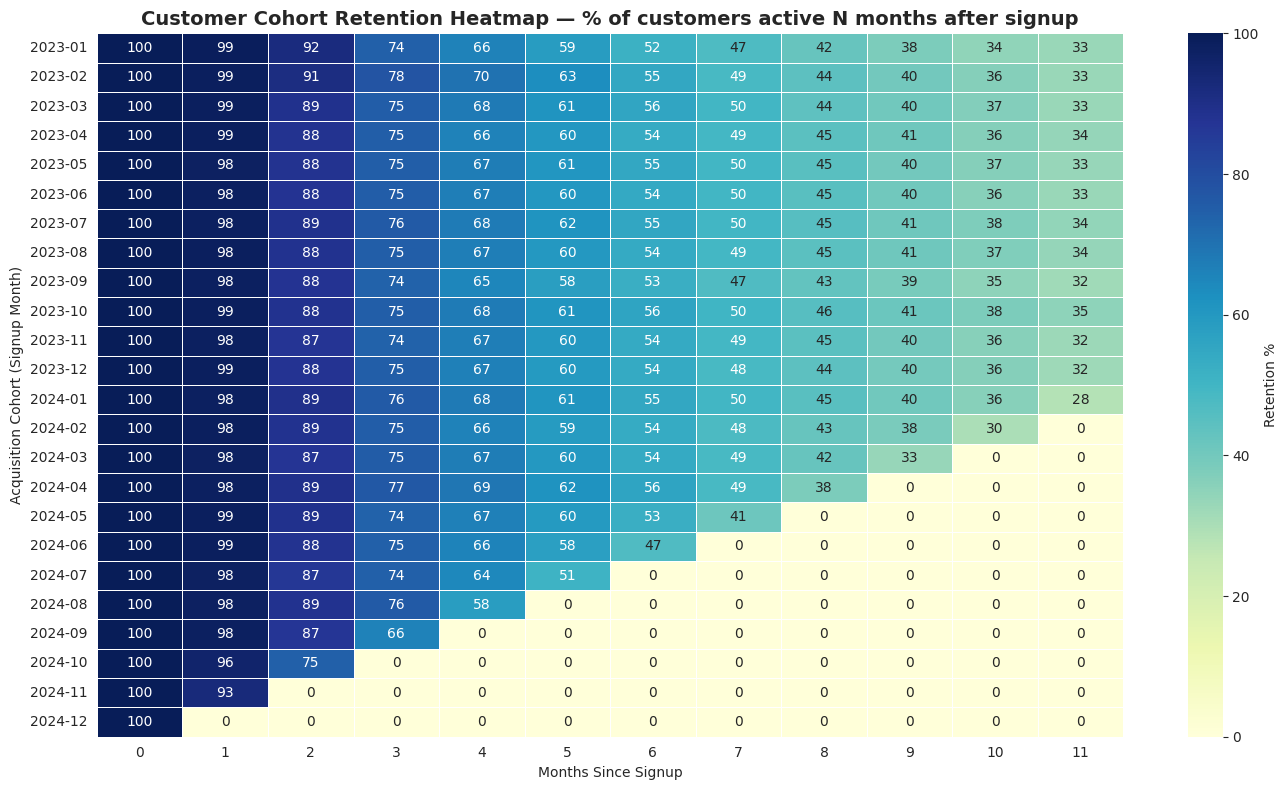

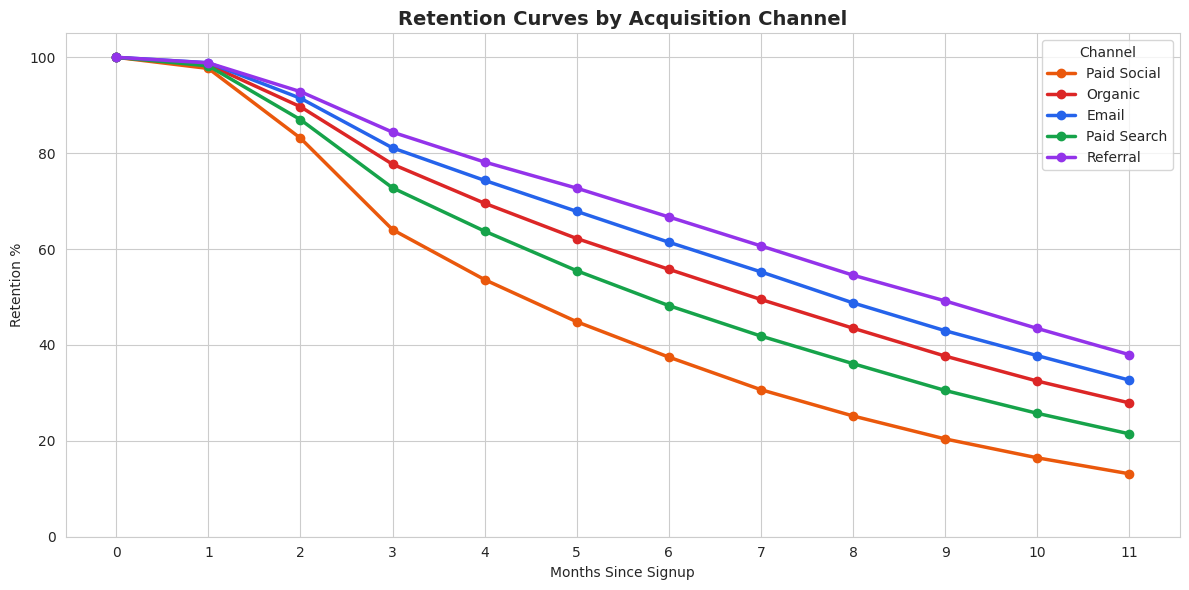

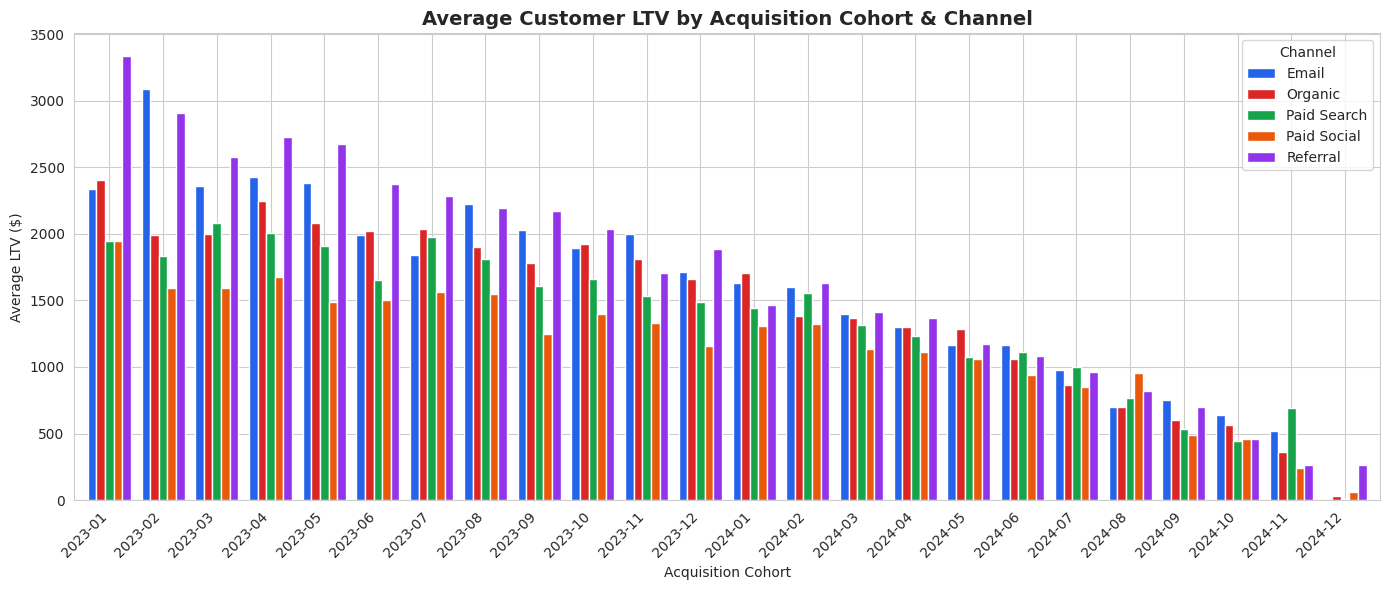

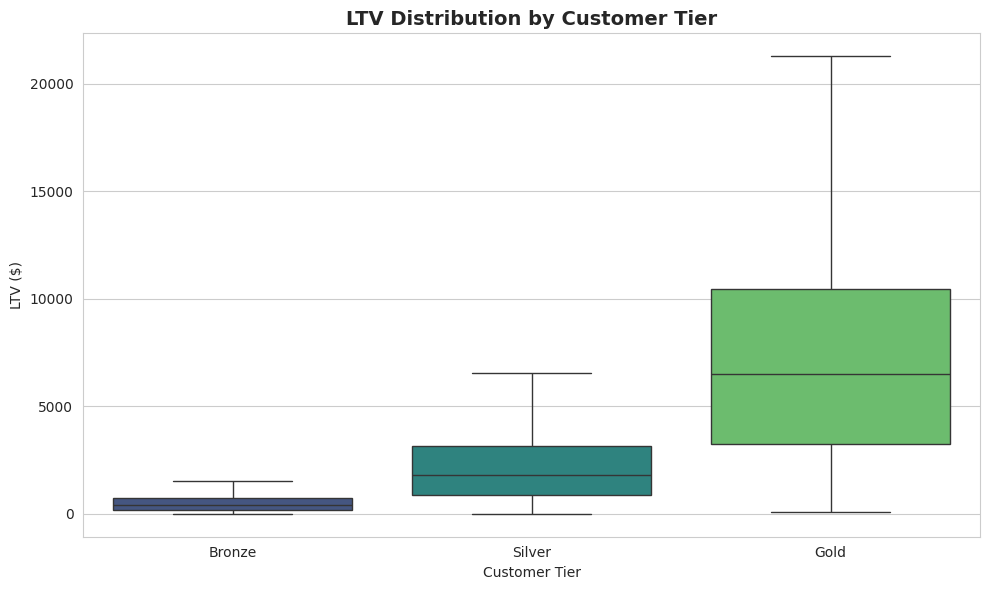


✅ All 4 charts saved


In [5]:
# === CHART 1: Retention Heatmap ===
heatmap_data = retention.iloc[:, :12]
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlGnBu',
            cbar_kws={'label': 'Retention %'}, linewidths=0.5, ax=ax)
ax.set_title('Customer Cohort Retention Heatmap — % of customers active N months after signup',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Months Since Signup')
ax.set_ylabel('Acquisition Cohort (Signup Month)')
plt.tight_layout()
plt.savefig('01_retention_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# === CHART 2: Retention Curves by Channel (FIXED LOGIC) ===
channel_rows = []
for channel in customer_last_active['channel'].unique():
    ch_data = customer_last_active[customer_last_active['channel'] == channel]
    ch_size = len(ch_data)
    row = {'channel': channel}
    for n in range(max_months):
        retained = (ch_data['last_active'] >= n).sum()
        row[n] = (retained / ch_size) * 100
    channel_rows.append(row)
channel_retention = pd.DataFrame(channel_rows).set_index('channel').clip(upper=100)

colors = {'Email': '#2563eb', 'Organic': '#dc2626', 'Paid Search': '#16a34a',
          'Paid Social': '#ea580c', 'Referral': '#9333ea'}
fig, ax = plt.subplots(figsize=(12, 6))
for ch in channel_retention.index:
    ax.plot(channel_retention.columns, channel_retention.loc[ch].values,
            marker='o', linewidth=2.5, color=colors.get(ch, 'gray'), label=ch)
ax.set_title('Retention Curves by Acquisition Channel', fontsize=14, fontweight='bold')
ax.set_xlabel('Months Since Signup')
ax.set_ylabel('Retention %')
ax.legend(title='Channel', loc='upper right')
ax.set_ylim(0, 105)
ax.set_xticks(range(0, 12))
plt.tight_layout()
plt.savefig('02_retention_by_channel.png', dpi=150, bbox_inches='tight')
plt.show()

# === CHART 3: LTV by Cohort × Channel ===
ltv_per_customer = df.groupby('customer_id')['amount'].sum().reset_index()
ltv_per_customer = ltv_per_customer.merge(customers[['customer_id', 'signup_month', 'channel']], on='customer_id')
avg_ltv = ltv_per_customer.groupby(['signup_month', 'channel'])['amount'].mean().reset_index()
ltv_pivot = avg_ltv.pivot(index='signup_month', columns='channel', values='amount')

fig, ax = plt.subplots(figsize=(14, 6))
ltv_pivot.plot(kind='bar', ax=ax,
               color=[colors.get(c, 'gray') for c in ltv_pivot.columns], width=0.8)
ax.set_title('Average Customer LTV by Acquisition Cohort & Channel', fontsize=14, fontweight='bold')
ax.set_xlabel('Acquisition Cohort')
ax.set_ylabel('Average LTV ($)')
ax.legend(title='Channel')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('03_ltv_by_channel.png', dpi=150, bbox_inches='tight')
plt.show()

# === CHART 4: LTV Distribution by Tier ===
ltv_with_tier = ltv_per_customer.merge(customers[['customer_id', 'tier']], on='customer_id')
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=ltv_with_tier, x='tier', y='amount',
            order=['Bronze', 'Silver', 'Gold'], palette='viridis', ax=ax, showfliers=False)
ax.set_title('LTV Distribution by Customer Tier', fontsize=14, fontweight='bold')
ax.set_xlabel('Customer Tier')
ax.set_ylabel('LTV ($)')
plt.tight_layout()
plt.savefig('04_ltv_by_tier.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ All 4 charts saved")

In [6]:
# Summary statistics
total_customers = len(customers)
total_revenue = txns['amount'].sum()
m3_retention = retention[3].dropna().mean()
m6_retention = retention[6].dropna().mean()
top_channel = channel_retention[6].idxmax()
top_channel_m6 = channel_retention.loc[top_channel, 6]

tier_avg_ltv = ltv_with_tier.groupby('tier')['amount'].mean()
ltv_gap_pct = (tier_avg_ltv['Gold'] / tier_avg_ltv['Bronze'] - 1) * 100

avg_ltv_per_cohort = ltv_pivot.mean(axis=1)
top_cohort = avg_ltv_per_cohort.idxmax()

# Save dataset files
customers.to_csv('customers.csv', index=False)
txns.to_csv('transactions.csv', index=False)

print("="*65)
print("🎯 KEY METRICS — Customer Cohort & Retention Analysis")
print("="*65)
print(f"Total customers analyzed:       {total_customers:,}")
print(f"Total transactions:             {len(txns):,}")
print(f"Total revenue:                  ${total_revenue:,.0f}")
print(f"Month-3 average retention:      {m3_retention:.1f}%")
print(f"Month-6 average retention:      {m6_retention:.1f}%")
print(f"Best-retaining channel @ M6:    {top_channel} ({top_channel_m6:.1f}%)")
print(f"Bronze avg LTV:                 ${tier_avg_ltv['Bronze']:.0f}")
print(f"Gold avg LTV:                   ${tier_avg_ltv['Gold']:.0f}")
print(f"Gold-vs-Bronze LTV gap:         {ltv_gap_pct:.0f}% higher")
print(f"Best-performing cohort (LTV):   {top_cohort}")
print("="*65)
print("\n✅ Files saved:")
print("   - 01_retention_heatmap.png")
print("   - 02_retention_by_channel.png")
print("   - 03_ltv_by_channel.png")
print("   - 04_ltv_by_tier.png")
print("   - customers.csv")
print("   - transactions.csv")

🎯 KEY METRICS — Customer Cohort & Retention Analysis
Total customers analyzed:       50,000
Total transactions:             692,428
Total revenue:                  $81,937,348
Month-3 average retention:      65.4%
Month-6 average retention:      40.4%
Best-retaining channel @ M6:    Referral (66.7%)
Bronze avg LTV:                 $499
Gold avg LTV:                   $7170
Gold-vs-Bronze LTV gap:         1336% higher
Best-performing cohort (LTV):   2023-01

✅ Files saved:
   - 01_retention_heatmap.png
   - 02_retention_by_channel.png
   - 03_ltv_by_channel.png
   - 04_ltv_by_tier.png
   - customers.csv
   - transactions.csv
